In [8]:
def process_couple(x):
    a, b = x.split(",")
    return int(a), int(b)
    
def process_line(line):
    p, v = line[2:].split(" v=")
    return process_couple(p), process_couple(v)

In [ ]:
with open("inputs/14", "r") as fp:
    data = fp.read()
    

data = data.split("\n")[:-1]

data = list(map(process_line, data))

In [12]:
w0 = 101 # Wide x
w1 = 103 # Tall y

In [13]:
p_end = []
for pos, vel in data:
    px, py = pos
    vx, vy = vel
    px0 = (px + vx* 100) % w0
    py0 = (py + vy* 100) % w1
    p_end.append((px0, py0))
    

##### Count quadrant

In [16]:
c00, c01, c10, c11 = 0, 0, 0, 0

w00 = w0 //2
w11 = w1 //2

for px, py in p_end:
    if (px == w00) | (py == w11):
        continue
    if (px < w00) & (py < w11):
        c00 += 1
    elif (px > w00) & (py < w11):
        c01 += 1
    elif (px > w00) & (py > w11):
        c11 += 1
    else:
        c10 += 1

print(c00, c01, c10, c11)

121 119 132 121


In [18]:
print(c00 * c01 * c10 * c11)

229980828


# Part 2

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
def count_quadrant(lst):
    c00, c01, c10, c11 = 0, 0, 0, 0
    
    w00 = w0 //2
    w11 = w1 //2
    
    for px, py in p_end:
        if (px == w00) | (py == w11):
            continue
        if (px < w00) & (py < w11):
            c00 += 1
        elif (px > w00) & (py < w11):
            c01 += 1
        elif (px > w00) & (py > w11):
            c11 += 1
        else:
            c10 += 1
    
    return (c00, c01, c10, c11)

In [42]:
lst_C = []
for T in range(10000):
    p_end = []
    for pos, vel in data:
        px, py = pos
        vx, vy = vel
        px0 = (px + vx* T) % w0
        py0 = (py + vy* T) % w1
        p_end.append((px0, py0))

    lst_C.append(count_quadrant(p_end))

In [49]:
C = np.array(lst_C)

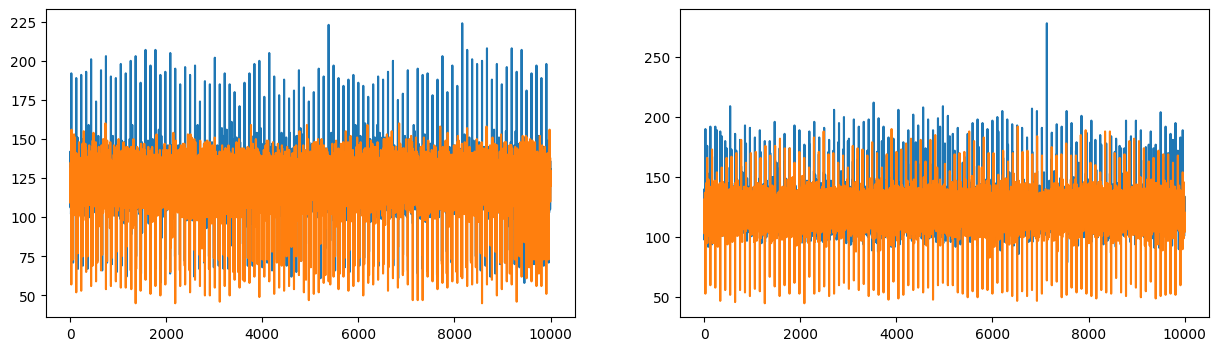

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

ax[0].plot(C[:, 0])
ax[1].plot(C[:, 1])
ax[0].plot(C[:, 2])
ax[1].plot(C[:, 3])


## Test

In [71]:
T = 7132
p_end = []
for pos, vel in data:
    px, py = pos
    vx, vy = vel
    px0 = (px + vx* T) % w0
    py0 = (py + vy* T) % w1
    p_end.append((px0, py0))


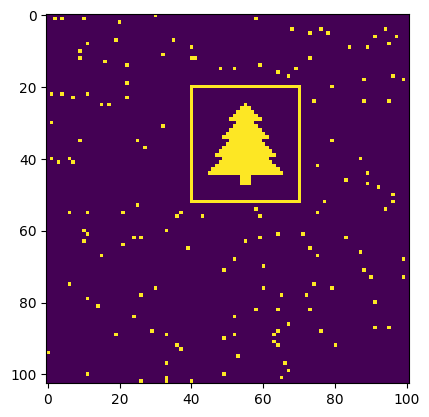

In [72]:
M = np.zeros((w1, w0))

for px, py in p_end:
    M[py, px] += 1

plt.imshow(M)